# Corregiendo los ERA5 e IMERG, EDA

Este notebook funciona para fijar, limpiar, y arreglar cualquier problemas con los datos de ERA5, IMERG, y los datos de las estaciones antes de construyo los pipelines de corregirlos.

## Imports & Constants

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr
import numpy as np

RAW_DIR = "../data/raw"
PROCESSED_DIR = "../data/processed"

## Data Load

In [27]:
df_station = pd.read_excel(RAW_DIR + "/PP_Temps_mensual_2000.xlsx")
df_station_tmax = pd.read_excel(
    RAW_DIR + "/PP_Temps_mensual_2000.xlsx", sheet_name="Tmax"
)
df_station_tmed = pd.read_excel(
    RAW_DIR + "/PP_Temps_mensual_2000.xlsx", sheet_name="Tmed"
)
df_station_tmin = pd.read_excel(
    RAW_DIR + "/PP_Temps_mensual_2000.xlsx", sheet_name="Tmin"
)

ds_era5 = xr.open_dataset(PROCESSED_DIR + "/era5_argentina_1980-2026.nc")

ds_imerg = xr.open_dataset(PROCESSED_DIR + "/imerg_argentina.nc")

print("Data loaded")

Data loaded


## Calidad de los datos estaciones precipitacion

Informacion de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3915 entries, 0 to 3914
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Estacion      3915 non-null   object 
 1   Departamento  3915 non-null   object 
 2   Provincia     3915 non-null   object 
 3   NH            3915 non-null   int64  
 4   Latitud       3915 non-null   float64
 5   Longitud      3915 non-null   float64
 6   Anio          3915 non-null   int64  
 7   ENE           3370 non-null   float64
 8   FEB           3346 non-null   float64
 9   MAR           3381 non-null   float64
 10  ABR           3400 non-null   float64
 11  MAY           3421 non-null   float64
 12  JUN           3307 non-null   float64
 13  JUL           3255 non-null   float64
 14  AGO           3249 non-null   float64
 15  SET           3308 non-null   float64
 16  OCT           3302 non-null   float64
 17  NOV           3302 non-null   float64
 18  DIC   

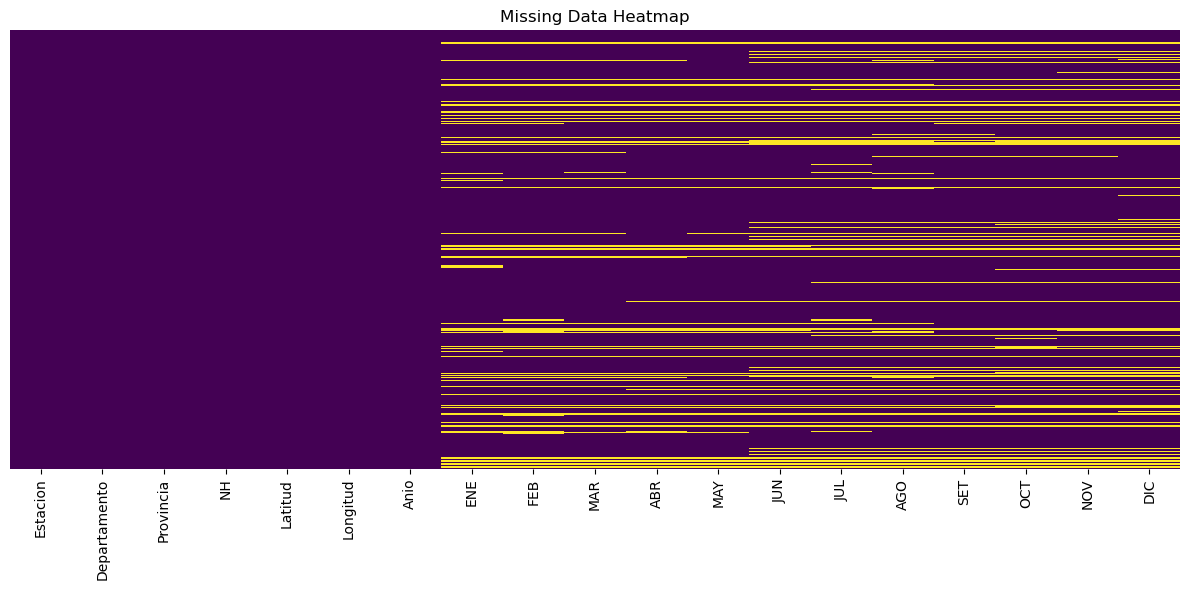

In [28]:
print("Informacion de datos:")
print(df_station.info())

print("\nPrimera 5 filas:")
print(df_station.head(5))

print("\nDatos faltando:")
print(df_station.isnull().sum())

print("\nResumen estadístico:")
print(df_station.describe())

plt.figure(figsize=(12, 6))
sns.heatmap(df_station.isnull(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Missing Data Heatmap")
plt.tight_layout()
plt.show()

## Calidad de los datos estaciones temperatura

In [29]:
print("--- T_MAX Statistical Summary ---")
display(df_station_tmax.describe())

print("\n--- T_MIN Statistical Summary ---")
display(df_station_tmin.describe())

tmax_max_val = (
    df_station_tmax[
        [
            "ENE",
            "FEB",
            "MAR",
            "ABR",
            "MAY",
            "JUN",
            "JUL",
            "AGO",
            "SET",
            "OCT",
            "NOV",
            "DIC",
        ]
    ]
    .max()
    .max()
)
print(f"\nAbsolute highest T_Max recorded: {tmax_max_val}")

tmin_min_val = (
    df_station_tmin[
        [
            "ENE",
            "FEB",
            "MAR",
            "ABR",
            "MAY",
            "JUN",
            "JUL",
            "AGO",
            "SET",
            "OCT",
            "NOV",
            "DIC",
        ]
    ]
    .min()
    .min()
)
print(f"Absolute lowest T_Min recorded: {tmin_min_val}")

--- T_MAX Statistical Summary ---


,NH,Latitud,Longitud,Anio,ENE,FEB,MAR,ABR,MAY,JUN,JUL,AGO,SET,OCT,NOV,DIC
count,3871.000000,3871.000000,3871.000000,3871.000000,3221.000000,3201.000000,3240.000000,3251.000000,3272.000000,3160.000000,3124.000000,3122.000000,3175.000000,3170.000000,3160.000000,3149.000000
mean,297.132524,-33.900589,-62.986265,2012.517179,30.652468,29.381818,27.067222,23.290065,18.925183,16.536646,16.225864,18.873030,21.340913,24.284637,27.173829,29.504541
std,215.864742,6.382114,4.124343,7.702085,3.752941,3.655487,3.784137,3.843192,3.923884,4.245616,4.592365,4.857556,4.741904,4.578582,4.169623,3.918826
min,1.000000,-54.800000,-72.050000,2000.000000,11.300000,11.100000,9.900000,7.700000,3.900000,-0.400000,-1.200000,3.200000,5.600000,8.700000,9.000000,10.400000
25%,138.000000,-36.750000,-65.730000,2006.000000,29.400000,27.800000,25.300000,21.500000,17.000000,14.500000,13.700000,16.000000,18.450000,21.400000,25.100000,28.100000
50%,283.000000,-33.120000,-62.730000,2012.000000,31.200000,29.700000,27.200000,23.600000,19.300000,16.800000,16.300000,18.800000,21.400000,24.350000,27.700000,30.100000
75%,453.000000,-29.230000,-59.680000,2019.000000,32.900000,31.500000,29.400000,25.800000,21.600000,19.300000,19.400000,22.500000,24.700000,27.500000,29.900000,31.900000
max,2700.000000,-22.100000,-54.470000,2026.000000,40.200000,39.800000,38.900000,33.700000,28.700000,27.900000,28.100000,31.100000,33.800000,37.000000,38.700000,38.900000



--- T_MIN Statistical Summary ---


,NH,Latitud,Longitud,Anio,ENE,FEB,MAR,ABR,MAY,JUN,JUL,AGO,SET,OCT,NOV,DIC
count,3873.000000,3873.000000,3873.000000,3873.000000,3240.000000,3217.000000,3259.000000,3268.000000,3288.000000,3178.000000,3136.000000,3131.000000,3192.000000,3180.000000,3175.000000,3158.000000
mean,298.110250,-33.865647,-62.941647,2012.474051,17.218148,16.543457,14.643633,11.323684,7.541667,4.902926,4.004177,5.421782,7.729104,11.047799,13.562803,15.795725
std,219.955226,6.403208,4.097958,7.700113,3.875759,3.946734,4.179384,4.308070,4.129224,4.356993,4.177666,4.062885,4.105939,4.353744,4.097500,3.968688
min,1.000000,-54.800000,-72.050000,2000.000000,4.300000,2.800000,1.300000,-2.200000,-4.800000,-8.000000,-10.600000,-8.200000,-3.800000,-1.500000,0.400000,3.200000
25%,138.000000,-36.750000,-65.600000,2006.000000,15.300000,14.300000,12.300000,8.600000,5.000000,1.925000,1.200000,2.600000,5.000000,8.100000,11.100000,13.600000
50%,283.000000,-33.080000,-62.620000,2012.000000,17.900000,17.000000,15.000000,11.600000,7.600000,4.500000,3.800000,5.300000,7.700000,11.200000,14.100000,16.400000
75%,453.000000,-29.230000,-59.680000,2019.000000,20.000000,19.400000,17.700000,14.400000,10.500000,7.700000,6.700000,8.000000,10.500000,14.100000,16.500000,18.600000
max,2700.000000,-22.100000,-54.470000,2026.000000,29.600000,27.600000,25.400000,23.300000,18.000000,17.100000,15.600000,17.100000,18.600000,23.200000,26.100000,26.700000



Absolute highest T_Max recorded: 40.2
Absolute lowest T_Min recorded: -10.6


## Cambiar y Combinar los datos de las estaciones 

Para corregir ERA5/Imerg, es necesario que este dataframe es en la forma larga y no como un spreadsheet.

In [ ]:
def clean_melt(df, value_name):
    df_long = df.melt(
        id_vars=[
            "Estacion",
            "Departamento",
            "Provincia",
            "NH",
            "Latitud",
            "Longitud",
            "Anio",
        ],
        value_vars=[
            "ENE",
            "FEB",
            "MAR",
            "ABR",
            "MAY",
            "JUN",
            "JUL",
            "AGO",
            "SET",
            "OCT",
            "NOV",
            "DIC",
        ],
        var_name="Mes_Texto",
        value_name=value_name,
    )
    mes_map = {
        "ENE": 1,
        "FEB": 2,
        "MAR": 3,
        "ABR": 4,
        "MAY": 5,
        "JUN": 6,
        "JUL": 7,
        "AGO": 8,
        "SET": 9,
        "OCT": 10,
        "NOV": 11,
        "DIC": 12,
    }
    df_long["Mes"] = df_long["Mes_Texto"].map(mes_map)

    df_long["Fecha"] = pd.to_datetime(
        df_long["Anio"].astype(str)
        + "-"
        + df_long["Mes"].astype(str).str.zfill(2)
        + "-01"
    )

    return df_long[
        [
            "Estacion",
            "Departamento",
            "Provincia",
            "Latitud",
            "Longitud",
            "Fecha",
            value_name,
        ]
    ]


df_precip = clean_melt(df_station, "Precipitacion")
df_tmax = clean_melt(df_station_tmax, "Tmax")
df_tmed = clean_melt(df_station_tmed, "Tmed")
df_tmin = clean_melt(df_station_tmin, "Tmin")

master_df = (
    df_precip.merge(
        df_tmax,
        on=["Estacion", "Departamento", "Provincia", "Latitud", "Longitud", "Fecha"],
        how="outer",
    )
    .merge(
        df_tmed,
        on=["Estacion", "Departamento", "Provincia", "Latitud", "Longitud", "Fecha"],
        how="outer",
    )
    .merge(
        df_tmin,
        on=["Estacion", "Departamento", "Provincia", "Latitud", "Longitud", "Fecha"],
        how="outer",
    )
)

master_df = master_df.dropna(
    subset=["Precipitacion", "Tmax", "Tmed", "Tmin"], how="all"
)

master_df.to_csv("../data/processed/fixed_station.csv", index=False)